# ML/Data Science Project - Classification

## Project outline

The aims of this project is to create a classification model that will allow us to predict the if a patient/individual has or has not had a stroke based off of certain feature variables- this can be useful in helping to predict whether or not a particular patient is at risk of suffering from a stroke in the near future. 

Data source: https://www.kaggle.com/datasets/jillanisofttech/brain-stroke-dataset  

### Models to be used

We can immediatly see that logistic regression can serve as an ideal model here as this model outputs probabilities. However, an underlying assumption with logistic regression is that the data itself shares a linear relationship with the target variable (as such, an alternative model, such as SVM or random forest  may be more reasonable). If this is the case, strategies to output probabilities from SVM or random forest models will be explored.

Regardless, even if an svm/random forest model is found to be more accurate, logistic regression will still be used as a baseline model in order to help facilitate better understanding of the dataset itself.

# EDA

In [1]:
# Importing libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Processed_datasets/Brain Stroke/brain_stroke_data.csv')

In [5]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,46.0,0,0,Yes,Private,Urban,78.79,42.4,smokes,0
1,Female,65.0,0,0,Yes,Self-employed,Urban,248.24,27.0,smokes,0
2,Male,70.0,1,0,Yes,Self-employed,Rural,118.81,26.0,smokes,0
3,Male,47.0,0,0,Yes,Private,Urban,111.84,33.7,Unknown,0
4,Male,31.0,0,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked,0


In [6]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [7]:
df.dtypes

gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [8]:
df.shape

(4482, 11)

In [9]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4482.000000,4482.000000,4482.000000,4482.000000,4482.000000,4482.000000
mean,43.446693,0.098394,0.054663,105.761430,28.466064,0.049755
std,22.592327,0.297879,0.227347,44.943627,6.764658,0.217462
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,26.000000,0.000000,0.000000,77.192500,23.600000,0.000000
50%,45.000000,0.000000,0.000000,91.680000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.637500,32.575000,0.000000
max,82.000000,1.000000,1.000000,267.760000,48.900000,1.000000


In [ ]:
#checking what are the unique answers for the categorical data

print(df['gender'].unique())
print(df['ever_married'].unique())
print(df['work_type'].unique())
print(df['Residence_type'].unique())
print(df['smoking_status'].unique())

['Female' 'Male']
['Yes' 'No']
['Private' 'Self-employed' 'Govt_job' 'children']
['Urban' 'Rural']
['smokes' 'Unknown' 'formerly smoked' 'never smoked']


In [50]:
#checking the data balance

print(df['stroke'].value_counts(),'\n')
print(df['gender'].value_counts(),'\n')
print(df['ever_married'].value_counts(),'\n')
print(df['work_type'].value_counts(),'\n')
print(df['Residence_type'].value_counts(),'\n')
print(df['smoking_status'].value_counts(),'\n')
print(df['hypertension'].value_counts(),'\n')
print(df['heart_disease'].value_counts())

stroke
0    4259
1     223
Name: count, dtype: int64 

gender
Female    2600
Male      1882
Name: count, dtype: int64 

ever_married
Yes    2951
No     1531
Name: count, dtype: int64 

work_type
Private          2571
Self-employed     721
children          602
Govt_job          588
Name: count, dtype: int64 

Residence_type
Urban    2282
Rural    2200
Name: count, dtype: int64 

smoking_status
never smoked       1665
Unknown            1352
formerly smoked     759
smokes              706
Name: count, dtype: int64 

hypertension
0    4041
1     441
Name: count, dtype: int64 

heart_disease
0    4237
1     245
Name: count, dtype: int64


In [27]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

### Initial comments:

- We can see from the above that we have ten feature variables and 4482 examples. We can immediately see that many of the features will require one hot encoding prior to training. Moreover, numerical features will also have to be normalised. 

- From my initial thoughts, prior to doing any visual analysis, the 'ever_married' do not seem too relevant wrt to predicting the liklihood of stroke- even if the models show that it is a strong indicator for stroke, we will still have to investigate there is genuine reason to believe that they have a causal relationship.

- One of the possible answers for 'smoking_status' is Unknown. Should keep an eye out for this when visually exploring the data.

- No null values in the dataset.

- Data is extremely inbalanced as we might expect- most do not have strokes. However, this demands that we carefully tune our model in order for it to be of any use (based off of this dataset alone, predicting that absolutly no one will have /has had a stroke will yield an accuracy of 95%). Thus, we need to look at other metrics other than accuracy such as the True positive (and negative) rate. We may need to also consider upsampling/downsampling the data to achieve more balance. Lastly, we notice that hypertension and heart disease seem to also be unbalanced, and the next section reveals average glucose levels to be unbalanced too.

### Graphing

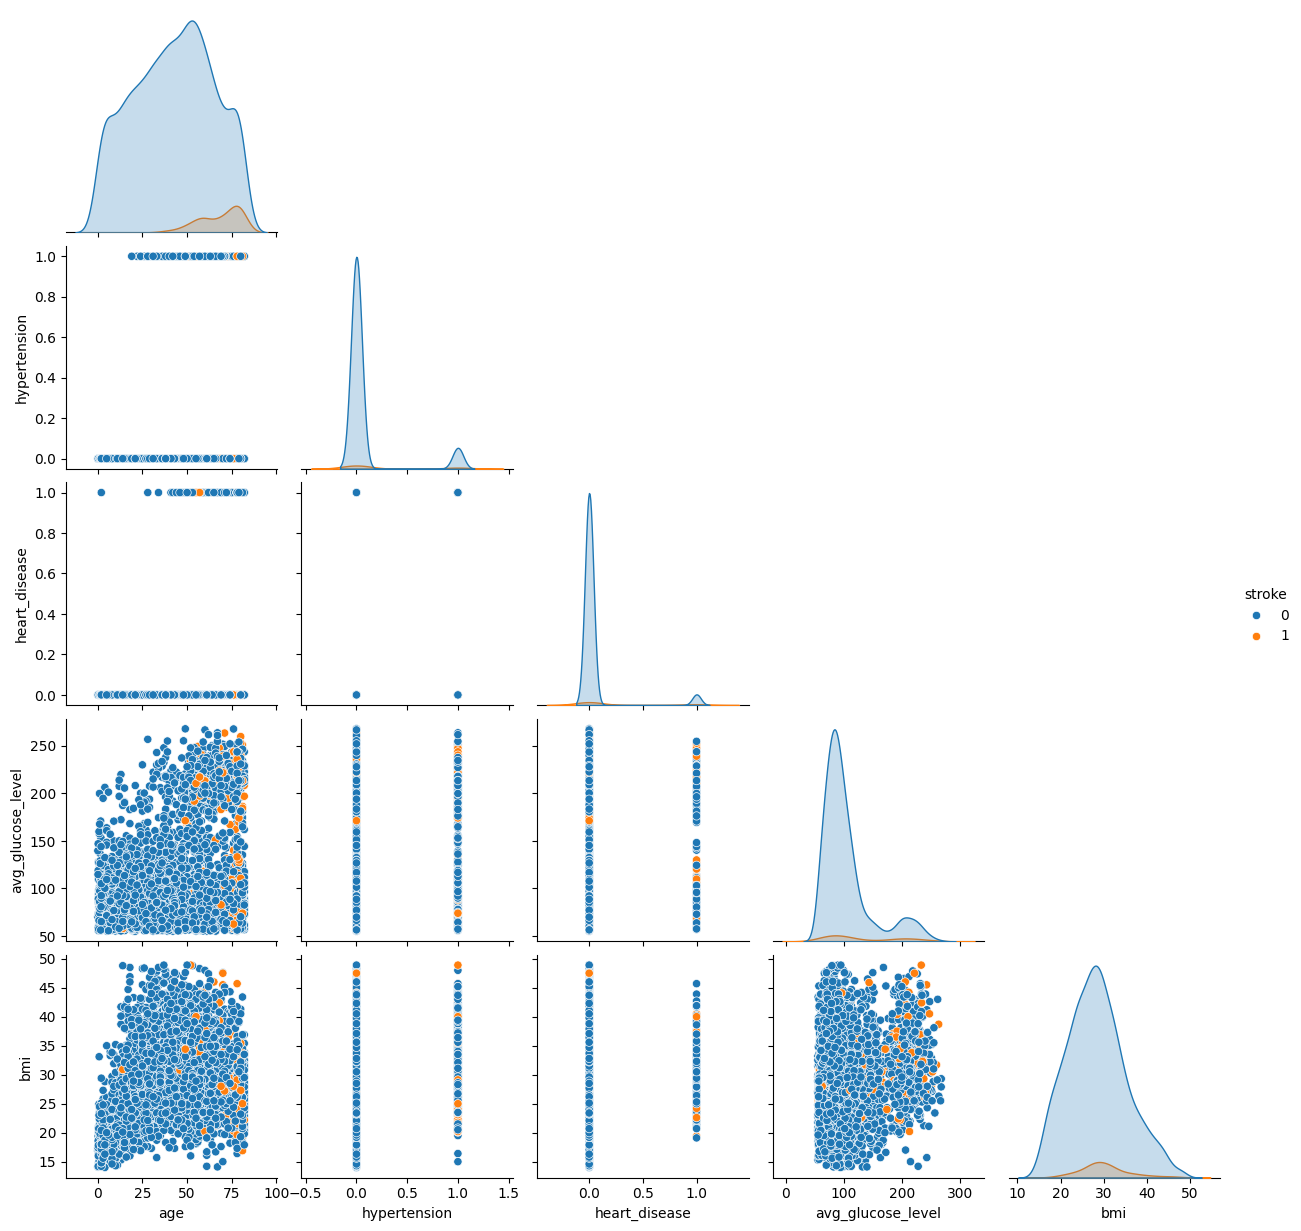

In [23]:
sns.pairplot(df, hue='stroke',corner=True)

<Axes: >

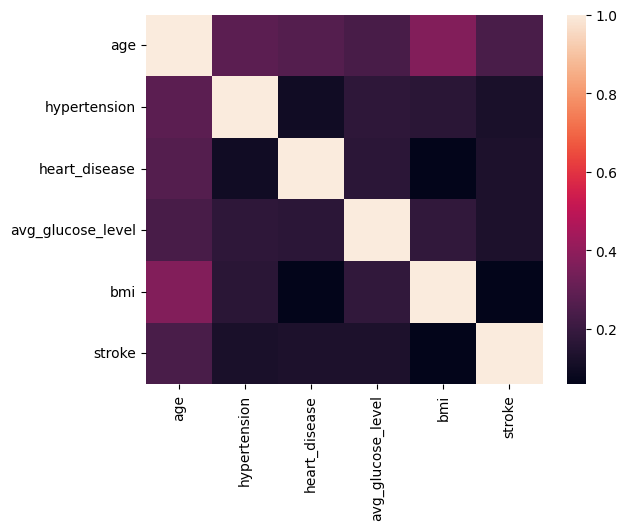

In [24]:
sns.heatmap(df.corr(numeric_only=True))

<Axes: >

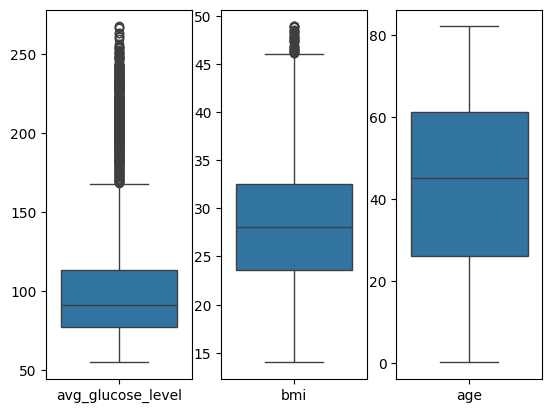

In [44]:
#define dimensions of subplots (rows, columns)
fig, axes = plt.subplots(1, 3)

#create chart in each subplot
sns.boxplot(data=df[['avg_glucose_level']], ax=axes[0])
sns.boxplot(data=df[['bmi']], ax=axes[1])
sns.boxplot(data=df[['age']], ax=axes[2])

<Axes: ylabel='Count'>

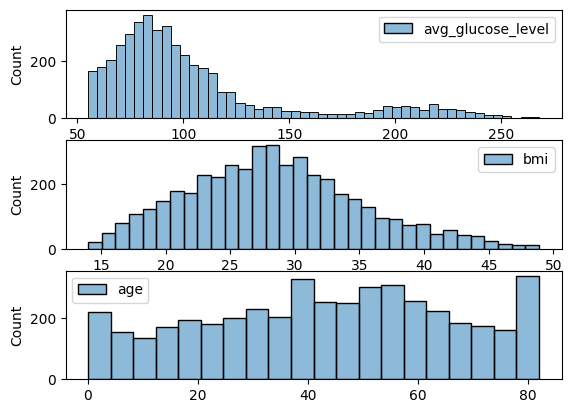

In [42]:
#define dimensions of subplots (rows, columns)
fig, axes = plt.subplots(3, 1)

#create chart in each subplot
sns.histplot(data=df[['avg_glucose_level']], ax=axes[0])
sns.histplot(data=df[['bmi']], ax=axes[1])
sns.histplot(data=df[['age']], ax=axes[2])

## EDA comments

### Avg_glucose level
The histogram above shows average glucose levels to be multimodal: the  value of the first peak resides around 80 whilst the second peak resides above 200. In addition, the boxplot considers the values above 150 (which is where the second peak begins to develop) to be outliers.

Glucose levels are most commonly known as blood sugar levels and are serve as the primary predictor for diabetes. Referencing https://diabetesstrong.com/what-levels-of-blood-sugar-are-dangerous/, we can assume that the avg_glucose level has units mg/dl and that values above 200 are indicative of diabetes whilst values less than 140 are considered normal. According to https://www.diabetes.org.uk/about-diabetes/looking-after-diabetes/complications/stroke#Why%20does%20diabetes%20increase%20your%20risk%20of%20a%20stroke?, diabetes is linked to a greater chance of stroke as it hightens the risk of heart disease. We can conclude from this that these supposed outliers must be kept.

### BMI
The histogram for BMI shows a bell shaped distribution with a slight tail at the end. BMI levels above 45 seem to reperesent outliers, however contextually, a BMI above 45 represents morbid obesity which is linked to diabetes, heart problems and high blood pressure. As such, the outliers here do not have to be removed. 

### Age 
Distribution of ages seems to be fairly balanced in the dataset, with the age having a notable peak. The  kernel density estimation plot (see pairplot) for the ages clearly shows that stroke victims are much likly to be of individuals above at least 40. Furthermore, the distribution for stroke victims has a negative skew, whereas for people who have never had a stroke the distribution is more normal.